In [1]:
### Context top 3 retrieved from RAG containing questions and answers based on similarity

context = ["""What is a Unix shell? Is Bash the only Unix shell?
A Unix shell is a software that provides a user interface for the underlying operating system. Unix shells typically provide a textual user interface - a command line interpreter - that may be used for entering and running commands, or create scripts that run a series of commands and can be used to express more advanced behavior.

Bash is not the only Unix shell, but just one of many. Short for Bourne-Again Shell, it is also one of the many Bourne-compatible shells. However, Bash is arguably one of the most popular shells around. There are other, modern shells available that often retain backwards compatibility with Bash but provide more functionality and features, such as the Z Shell (zsh).""",

"""What are shared, slave, private, and unbindable mountpoints?
A mount point that is shared may be replicated as many times as needed, and each copy will continue to be the exact same. Other mount points that appear under a shared mount point in some subdirectory will appear in all the other replicated mount points as it is.

A slave mount point is similar to a shared mount point with the small exception that the “sharing” of mount point information happens in one direction. A mount point that is slave will only receive mount and unmount events. Anything that is mounted under this replicated mount point will not move towards the original mount point.

A private mount point is exactly what the name implies: private. Mount points that appear under a private mount point will not be shown elsewhere in the other replicated mount points unless they are explicitly mounted there as well.

An unbindable mount point, which by definition is also private, cannot be replicated elsewhere through the use of the bind flag of the mount system call or command.""",

"""What is a swap space?
Swap space is a certain amount of space used by Linux to temporarily hold some programs that are running concurrently. This happens when RAM does not have enough memory to hold all programs that are executing."""]

In [2]:
from dotenv import load_dotenv
from typing import TypedDict, List, Annotated
import operator
from __future__ import annotations
from pydantic import BaseModel, Field
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, Send, interrupt
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage

In [3]:
load_dotenv()

True

In [4]:
class QA(BaseModel):
    question: str = Field(description="Question to be answered")
    expected_answer: str = Field(description="Expected answer to the question")
    given_answer: str = Field(description="Answer provided by the user")

class QAList(BaseModel):
    qa_list: List[QA] = Field(description="List of question and answers")

class Feedback(BaseModel):
    qa: QA = Field(description="Question and answer pair")
    similarity: float = Field(description="Similarity score between the expected answer and the given answer")
    feedback: str = Field(description="Feedback to be generated by model")
    
class State(TypedDict):
    topic: str
    qa_list: List[QA]
    completed_qa: Annotated[list, operator.add]
    feedback: List[Feedback]

In [5]:
def generate_question(state: State):
    """Generate a question based on the context provided."""
    # Initialize the chat model
    chat_model = init_chat_model(model_provider="openai", model="gpt-4o-mini")
    
    chat_model_with_structured_output = chat_model.with_structured_output(QAList)
    
    # Create a system message with the context
    system_message = SystemMessage(
        content=f"You are an expert technical quizmaster, your task is to generate at least 2 quiz questions QAList using the context provided to you: \n\n{str(context)}\n\n. Each QA should have question, expected_answer fields."
    )
    
    # Create a human message to ask for a question
    human_message = HumanMessage(
        content="Please generate a question based on the provided context."
    )
    
    # Send the messages to the chat model and get the response
    response = chat_model_with_structured_output.invoke([system_message, human_message])
    # print("generate question llm response", response)
    # Extract the generated question from the response
    generated_qa_list = response.qa_list
    # print("generated_qa_list", generated_qa_list)
    return {"qa_list": generated_qa_list}

def human_node(state: State):
    """Human node to get the answer from the user."""
    # Display the question and context
    # print(f"Question: {state['qa_list'][-1].question}")
    # print(f"Context: {context}")
    
    # Get the answer from the user
    user_answer = interrupt(f"Question: {state['qa_list'][-1].question} \n Please provide your answer:")
    
    # Update the last QA object with the user's answer
    state['qa_list'][-1].given_answer = user_answer
    
    return {"completed_qa": [state['qa_list'][-1]]}

def generate_feedback(state: State):
    """Generate feedback based on the answer provided by the user."""
    # Initialize the chat model
    chat_model = init_chat_model(model_provider="openai", model="gpt-4o-mini")
    
    chat_model_with_structured_output = chat_model.with_structured_output(Feedback)
    
    # Create a system message with the context
    system_message = SystemMessage(
        content=f"You are an expert technical quizzer, You are given the question, expected_answer, given_answer: \n\n{str(state['completed_qa'][-1])}\n\n. Based on this information, generate feedback for the user. The feedback should include a similarity score between the expected answer and the given answer, and a brief explanation of the score. The feedback should be in the format: \n\n{{\"similarity\": <similarity_score>, \"feedback\": <feedback>}}"
    )
    
    # Create a human message to ask for feedback
    human_message = HumanMessage(
        content="Please generate feedback based on the provided context."
    )
    
    # Send the messages to the chat model and get the response
    response = chat_model_with_structured_output.invoke([system_message, human_message])
    print("feedback llm response", response)
    
    return {"feedback": [response]}

In [6]:
poc_workflow = StateGraph(State)
poc_workflow.add_node("generate_question",generate_question)
poc_workflow.add_node("human_node",human_node)
poc_workflow.add_node("generate_feedback",generate_feedback)

poc_workflow.add_edge(START,"generate_question")
poc_workflow.add_edge("generate_question","human_node")
poc_workflow.add_edge("human_node","generate_feedback")
poc_workflow.add_edge("generate_feedback",END)

checkpointer = MemorySaver()
graph = poc_workflow.compile(checkpointer=checkpointer)

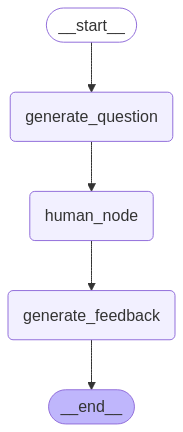

In [7]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
thread = {"configurable": {"thread_id": "poc_thread_fail_case"}}

In [9]:
async for event in graph.astream({"topic":"UNIX SYSTEMS",}, thread, stream_mode="updates"):
    print(event)
    print("\n")
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(interrupt_value)
        graph.invoke(Command(resume=input("Enter your answer:")), config=thread)
    

{'generate_question': {'qa_list': [QA(question='What is the main purpose of a Unix shell?', expected_answer='A Unix shell provides a user interface for the underlying operating system, allowing users to enter and run commands or create scripts.', given_answer=''), QA(question='What distinguishes a shared mount point from a private mount point?', expected_answer='A shared mount point replicates mount points across various locations, while a private mount point does not show any mounted points elsewhere unless specifically mounted there.', given_answer='')]}}


{'__interrupt__': (Interrupt(value='Question: What distinguishes a shared mount point from a private mount point? \n Please provide your answer:', resumable=True, ns=['human_node:f1ed277f-21c0-4506-60d1-485caaed133e']),)}




'Question: What distinguishes a shared mount point from a private mount point? \n Please provide your answer:'

feedback llm response qa=QA(question='What distinguishes a shared mount point from a private mount point?', expected_answer='A shared mount point replicates mount points across various locations, while a private mount point does not show any mounted points elsewhere unless specifically mounted there.', given_answer='python is a snake') similarity=0.0 feedback='Your answer does not relate to the question at all. A similarity score of 0.0 indicates that there is no connection between your answer and the expected answer. Please focus on concepts related to mount points in file systems.'


In [10]:
thread = {"configurable": {"thread_id": "poc_thread_pass_case"}}

In [11]:
async for event in graph.astream({"topic":"UNIX SYSTEMS",}, thread, stream_mode="updates"):
    print(event)
    print("\n")
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(interrupt_value)
        graph.invoke(Command(resume=input("Enter your answer:")), config=thread)

{'generate_question': {'qa_list': [QA(question='What distinguishes a shared mount point from a private mount point in Unix systems?', expected_answer='A shared mount point allows for replication and any changes made under it are reflected in all instances, while a private mount point does not share its contents with others and any mounts under it are only visible to it unless explicitly mounted elsewhere.', given_answer=''), QA(question='What is the function of swap space in a Linux operating system?', expected_answer='Swap space is used by Linux to temporarily hold programs that are running concurrently when the RAM is insufficient to contain all executing programs.', given_answer='')]}}


{'__interrupt__': (Interrupt(value='Question: What is the function of swap space in a Linux operating system? \n Please provide your answer:', resumable=True, ns=['human_node:8e899259-00c5-79ab-8c0f-6912b0625706']),)}




'Question: What is the function of swap space in a Linux operating system? \n Please provide your answer:'

feedback llm response qa=QA(question='What is the function of swap space in a Linux operating system?', expected_answer='Swap space is used by Linux to temporarily hold programs that are running concurrently when the RAM is insufficient to contain all executing programs.', given_answer='The function of swap space in a Linux operating system is to provide additional virtual memory when physical RAM is full. It temporarily stores data that is not actively in use, allowing the system to continue running without crashing, though access to swap is slower than RAM.') similarity=0.85 feedback='Your answer captures the essence of what swap space does by mentioning its role in providing additional virtual memory and maintaining system stability during memory shortages. The expected answer focuses more specifically on the concurrent execution of programs when RAM is insufficient. The similarity score of 0.85 reflects this close alignment, with some variations in wording and emphasis.'
